# 10. Reaction-Diffusion: Turing Patterns

In 1952 Alan Turing proposed that two chemicals, doing nothing but reacting and spreading, could paint the leopard. Today we simulate his idea in numpy, grow spots, stripes, corals and labyrinths from a single seed, and ask what it means for ornament that nature turns out to compute its patterns.

## Today's destination

A labyrinth grown, not drawn: the Gray-Scott reaction-diffusion system in its maze regime, run from one square seed until walls fill the canvas. No line in this image was placed by anyone; the chemistry negotiated every turn. By the end of today you can grow six different pattern species from the same five lines of update code.

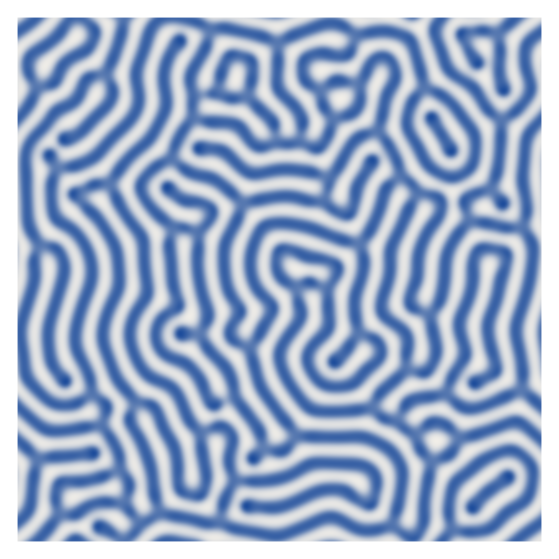

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch10_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the mathematician and the leopard

**Alan Turing** published "The Chemical Basis of Morphogenesis" in 1952, two years before his death, and it reads like nothing else he wrote: a founder of computer science proposing, with full differential-equation seriousness, an explanation for the patterns on animals. His idea needs only two interacting substances he called **morphogens**: one that activates pattern locally, one that inhibits it over a longer range, both diffusing through tissue. Uniform gray, Turing showed, can be *unstable*: the slightest unevenness gets amplified into regular spots or stripes whose spacing is set by the chemistry, not by any blueprint. The paper was decades ahead of its evidence; experimental support arrived slowly, from the stripes of the angelfish *Pomacanthus* (1995) to the ridged pattern of the mouse palate (2012), and pattern-formation theory is now a standard part of developmental biology. The science writer **Philip Ball**'s trilogy *Nature's Patterns* (2009) is the grand tour of this world, and its recurring hero is Turing.

We simulate the **Gray-Scott model**, a two-chemical reactor system from the 1980s whose computational behavior **John Pearson** surveyed in a famous 1993 *Science* paper: sweeping just two dials, a *feed* rate $f$ and a *kill* rate $k$, he mapped out a dozen regimes of spots, stripes, waves and chaos. (Pearson labeled them with Greek letters; the nicknames we use, coral, mitosis, worms, come from the generative-art community that adopted the model.)

Why does this belong in an art history course? Because ornament has always shadowed nature's patterns, and reaction-diffusion sharpens an old question. **William Morris** drew *Willow Bough* (1887) from willows he could see; **Hermann Obrist**'s whiplash embroidery (c. 1895) abstracted plant energy into Jugendstil's signature curve; and **Owen Jones**, back in chapter 3, had already insisted that good ornament follows nature's *principles* rather than copying her surfaces. Turing hands us the sharpest version of that program: not imitating nature's forms, and not even her principles of arrangement, but running her *process*. When today's showpiece looks like coral, no one imitated coral; pattern and reef share an algorithm. Whether that makes the result more natural or less, more designed or less, is a genuinely open question, and it is yours to argue about in the gallery.

## Diffusion is local averaging

Two ingredients build the whole simulation, and the first is **diffusion** (Diffusion): stuff spreads. On a pixel grid, spreading means every cell drifts toward the average of its neighborhood, and the operator that measures "how far below my neighbors' average am I" is the **discrete Laplacian**, a 3x3 convolution kernel:

$$\nabla^2 \approx \begin{pmatrix} 0.05 & 0.2 & 0.05 \\ 0.2 & -1 & 0.2 \\ 0.05 & 0.2 & 0.05 \end{pmatrix}$$

The weights sum to zero: a flat region gets zero change, a lonely peak gets pulled down, a hole gets filled. This is chapter 9's `convolve` doing all the work again, as promised. Watch pure diffusion erase a square:

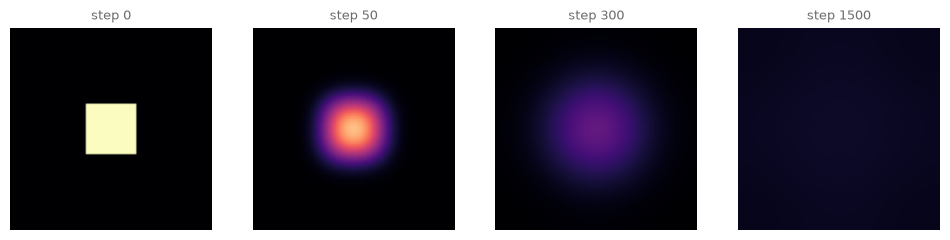

In [2]:
# diffusion alone: a square spot melting under the Laplacian
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

LAPLACIAN = np.array([[0.05, 0.2, 0.05],
                      [0.2, -1.0, 0.2],
                      [0.05, 0.2, 0.05]])

spot = np.zeros((80, 80))
spot[30:50, 30:50] = 1.0

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
snapshots = [0, 50, 300, 1500]
u = spot.copy()
for step in range(snapshots[-1] + 1):
    if step in snapshots:
        ax = axes[snapshots.index(step)]
        ax.imshow(u, cmap="magma", vmin=0, vmax=1)
        ax.set_title(f"step {step}", fontsize=9, color="#6B6B6B")
        ax.axis("off")
    u += convolve(u, LAPLACIAN, mode="wrap")
plt.show()

Left alone, diffusion ends in uniform gray soup: pure entropy, no pattern. The second ingredient fights back.

## Reaction joins diffusion

The **Gray-Scott system** tracks two chemicals on the same grid: $u$ (the *feedstock*, everywhere initially) and $v$ (the *pattern-maker*, seeded in one patch). Three things happen at once: the reaction $u + 2v \to 3v$, in which $v$ eats $u$ to make more $v$; a **feed** that tops $u$ back up toward 1 at rate $f$; and a **kill** that drains $v$ away at rate $k$. With diffusion added (and $u$ spreading twice as fast as $v$), the update equations are:

$$\frac{\partial u}{\partial t} = D_u \nabla^2 u \; - \; uv^2 \; + \; f\,(1 - u)$$

$$\frac{\partial v}{\partial t} = D_v \nabla^2 v \; + \; uv^2 \; - \; (f + k)\,v$$

Term by term, in words: *spread, get eaten, get refilled* for $u$; *spread, grow by eating, die off* for $v$. That is the entire model. The activator-inhibitor tension Turing asked for hides in the rates: $v$ promotes itself (autocatalysis) but its food diffuses in faster than it does, so growth saturates and spaces itself out. Patterns are the negotiation.

In [3]:
# one Gray-Scott step, and a seeded starting state
def gray_scott_step(u, v, f, k, du=1.0, dv=0.5):
    lap_u = convolve(u, LAPLACIAN, mode="wrap")
    lap_v = convolve(v, LAPLACIAN, mode="wrap")
    reaction = u * v * v                     # the u + 2v -> 3v encounter rate
    u_next = u + du * lap_u - reaction + f * (1 - u)
    v_next = v + dv * lap_v + reaction - (f + k) * v
    return u_next, v_next

def seeded_state(size, seed, patch=None):
    rng = np.random.default_rng(seed)
    u = np.ones((size, size))
    v = np.zeros((size, size))
    half = size // 10 if patch is None else patch
    center = size // 2
    u[center - half:center + half, center - half:center + half] = 0.5
    v[center - half:center + half, center - half:center + half] = 0.25
    u += rng.uniform(-0.02, 0.02, u.shape)   # a whisper of unevenness
    v += rng.uniform(-0.02, 0.02, v.shape)   # (Turing's instability needs it)
    return u, v

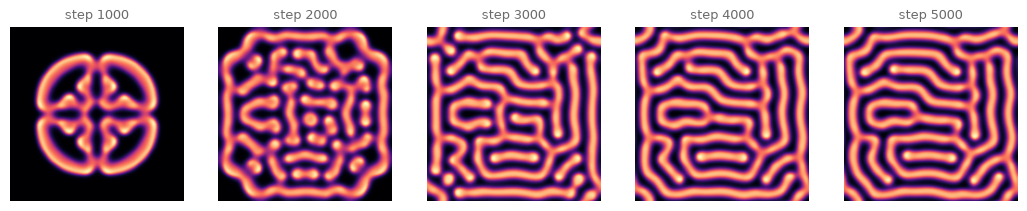

In [4]:
# run the maze regime from the center seed; snapshot every thousand steps
u, v = seeded_state(size=160, seed=1)
snapshots = [1000, 2000, 3000, 4000, 5000]

fig, axes = plt.subplots(1, 5, figsize=(13, 2.9))
for step in range(1, snapshots[-1] + 1):
    u, v = gray_scott_step(u, v, f=0.029, k=0.057)
    if step in snapshots:
        ax = axes[snapshots.index(step)]
        ax.imshow(v, cmap="magma")
        ax.set_title(f"step {step}", fontsize=9, color="#6B6B6B")
        ax.axis("off")
plt.show()

The seed erupts, fingers reach out, fingers negotiate spacing, and a labyrinth crystallizes outward with a preferred wall thickness that no parameter states directly; it *emerges* from the race between feeding and killing (chapter 9's word, now in continuous form). Five thousand steps of pure local arithmetic; nothing in the code knows what a maze is.

**Try it.** In the running cell, nudge `k` to `0.061` and rerun: same seed, entirely different species. Millimeters matter in the $(f, k)$ plane, which is exactly why Pearson drew a map of it.

## The map of species

Our six chosen settlements on Pearson's map, each named for what you will see. The diagram (axes on: this is a map, not an artwork) shows where they sit; the gallery below actually grows each one. All six run the identical `gray_scott_step`; only $(f, k)$ changes.

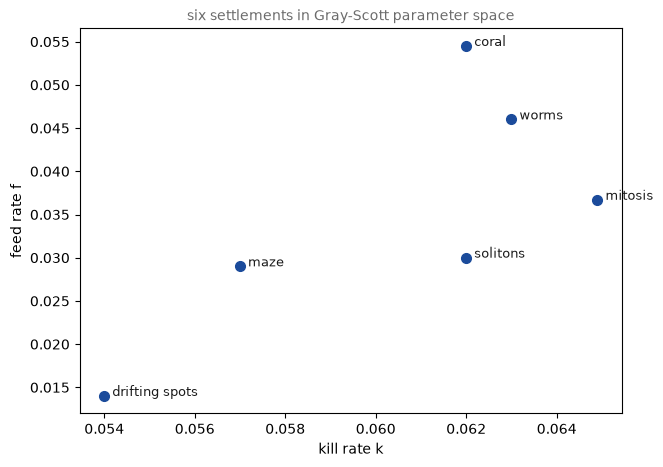

In [5]:
# six (f, k) presets, located on the feed-kill plane
PRESETS = {
    "coral":     (0.0545, 0.062),
    "mitosis":   (0.0367, 0.0649),
    "maze":      (0.029, 0.057),
    "solitons":  (0.03, 0.062),
    "worms":     (0.046, 0.063),
    "drifting spots": (0.014, 0.054),
}

plt.figure(figsize=(7, 5))
for name, (f, k) in PRESETS.items():
    plt.plot(k, f, "o", color="#1B4B9B", markersize=7)
    plt.annotate(f"  {name}", (k, f), fontsize=9, color="#1A1A1A")
plt.xlabel("kill rate k")
plt.ylabel("feed rate f")
plt.title("six settlements in Gray-Scott parameter space", fontsize=10,
          color="#6B6B6B")
plt.show()

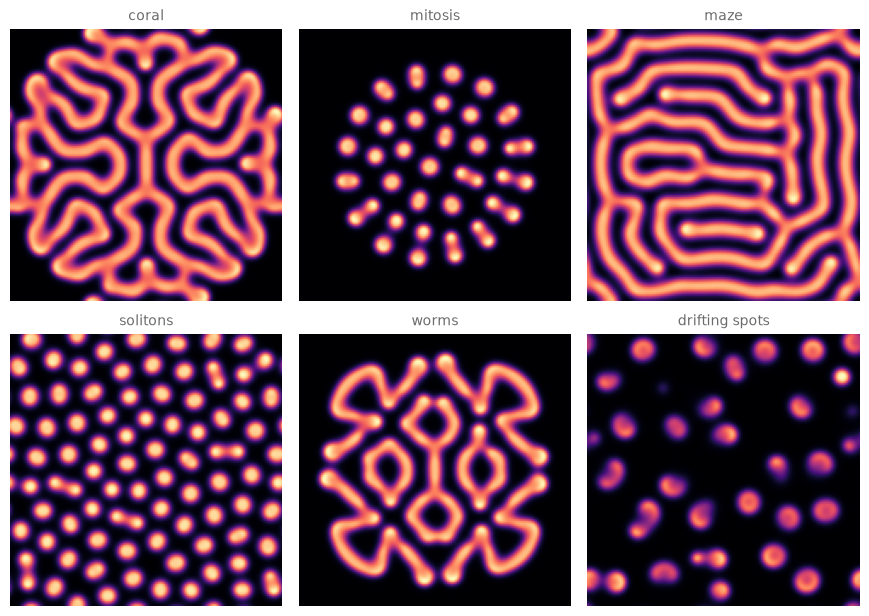

In [6]:
# grow all six: same code, same seed shape, six species (about half a minute)
def grow(preset, size=160, steps=5000, seed=1):
    f, k = PRESETS[preset]
    u, v = seeded_state(size, seed)
    for step in range(steps):
        u, v = gray_scott_step(u, v, f, k)
    return v

fig, axes = plt.subplots(2, 3, figsize=(11, 7.5))
for ax, name in zip(axes.flat, PRESETS):
    ax.imshow(grow(name), cmap="magma")
    ax.set_title(name, fontsize=10, color="#6B6B6B")
    ax.axis("off")
fig.subplots_adjust(wspace=0.05, hspace=0.12)
plt.show()

Six patterns, one law. *Mitosis* earns its name in motion: its dots grow, pinch, and divide like cells (rerun with `steps=2000` to catch them mid-split). *Drifting spots* never settles at all; what you see is one frame of a perpetual migration. And *coral* at this point is still growing; give it 10000 steps and it fills the frame. The deep lesson sits in the pairing of *maze* and *solitons*: their parameters differ by half a percent, their outputs belong to different worlds. Developmental biologists suspect exactly such knife-edges separate the leopard from the cheetah.

## Style pass: chemistry in course colors

Grayscale-plus-colormap is the diagnostic view. For artwork we map the $v$ concentration onto a two-color gradient of our own, chapter 5's lesson that the palette *is* the picture. `LinearSegmentedColormap.from_list` builds a colormap from any two hex colors, and suddenly the same chemistry prints as indigo porcelain, riso poster, or moss on limestone.

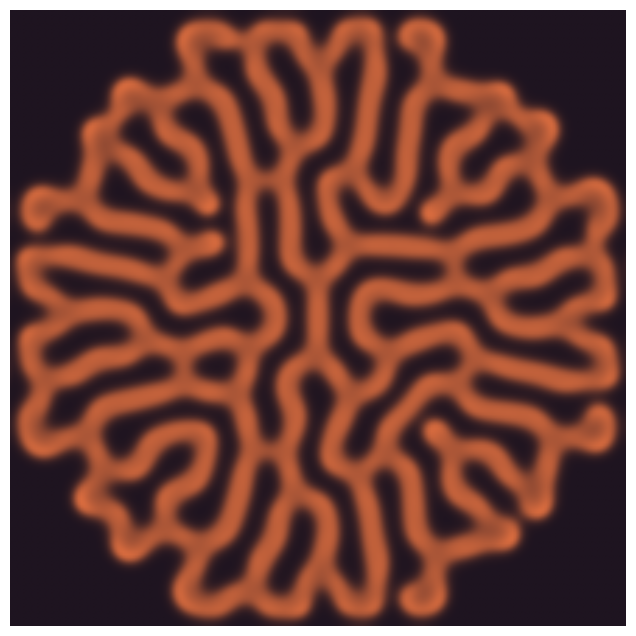

In [7]:
# the finished generator: a preset, two colors, print-ready chemistry
import sys
sys.path.append("..")
from matplotlib.colors import LinearSegmentedColormap
from agap.helpers import PAPER, save_artwork

def turing_art(preset, low="#F2EFE9", high="#1B4B9B", size=220, steps=6000,
               seed=1, figsize=8):
    field = grow(preset, size, steps, seed)
    colormap = LinearSegmentedColormap.from_list("duo", [low, high])
    fig = plt.figure(figsize=(figsize, figsize))
    plt.imshow(field, cmap=colormap, interpolation="bilinear")
    plt.axis("off")
    plt.show()
    return fig

art_1 = turing_art("coral", low="#1E1420", high="#D96C3F")

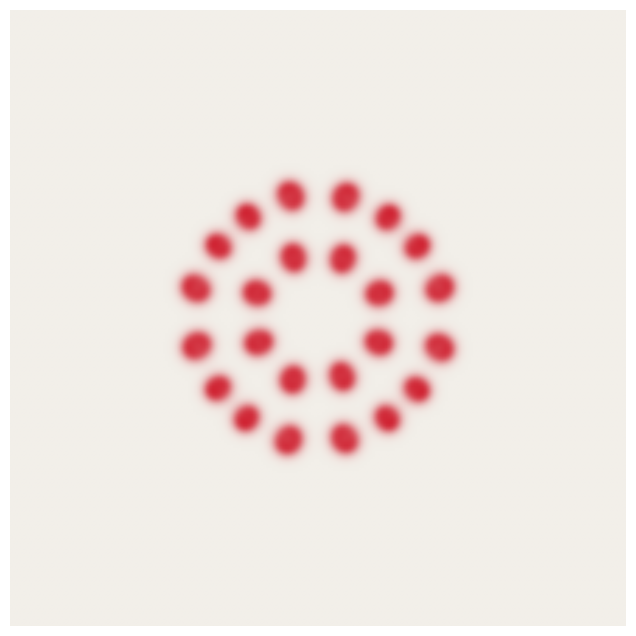

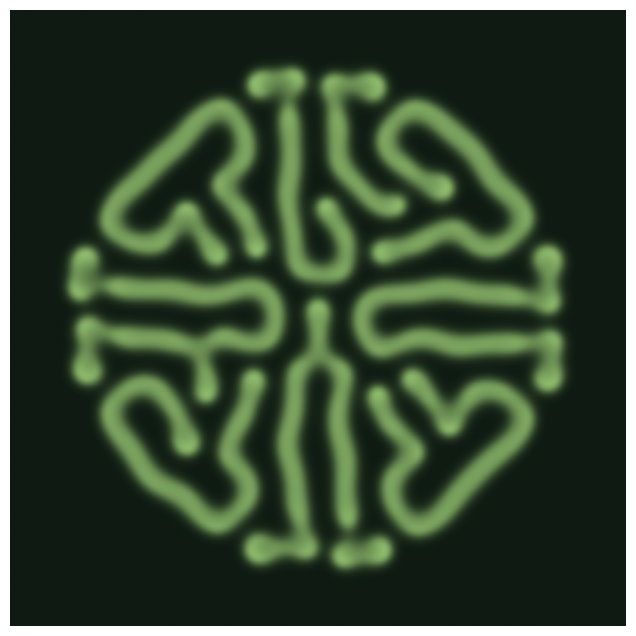

In [8]:
# temperament 2 and 3: dividing cells in Bauhaus red, worms in deep moss
art_2 = turing_art("mitosis", low="#F2EFE9", high="#D02433", steps=3500)
art_3 = turing_art("worms", low="#0E1A12", high="#8FBC6D")

**Look and compare.** The coral in ember orange reads as organic, almost wet; the same coral in gray reads as an X-ray. Which two-color pairing makes the *mitosis* dots most unsettling, and is the discomfort in the pattern or in the palette? William Morris insisted a wallpaper needed "order" behind its nature; rank the three panels by how wallpaper-able they are, and try to name the property that disqualifies the losers.

## Export your artwork

Choose a species, choose two colors, grow yours. Replace `yourname` and run; the print-quality PNG lands in `assets/outputs/`. (Patience beats resolution: doubling `size` quadruples the work *and* the pattern needs proportionally more steps to fill the frame.)

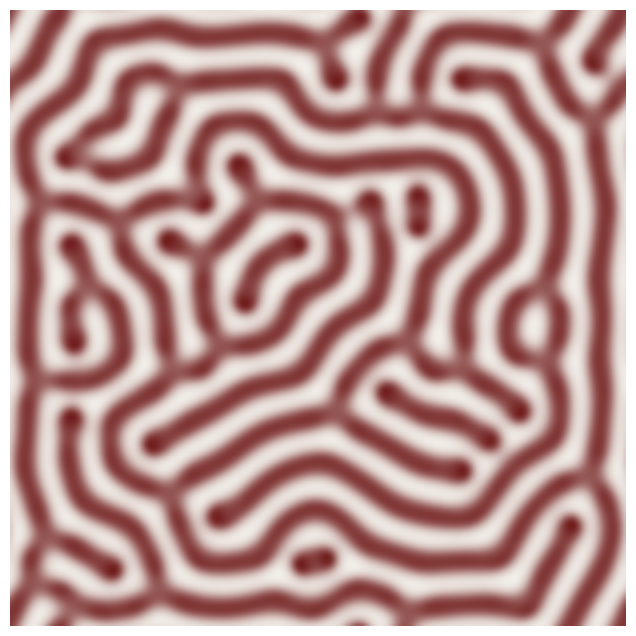

saved: assets/outputs/ch10_yourname.png


In [9]:
# save YOUR artwork: adjust preset, colors, steps, replace 'yourname', run
my_artwork = turing_art("maze", low="#F2EFE9", high="#701C1C", seed=2026)
saved_path = save_artwork(my_artwork, "yourname", chapter=10)

## Exercises

**(a) Parameter exploration: rain instead of one seed.** Replace the center-patch seeding in `seeded_state` with several small patches at random positions (a loop over `rng.integers` corner coordinates works). Grow the maze preset from 1, 5, and 20 seeds. Where colonies meet, sutures form: compare the texture of a one-seed maze with a twenty-seed one. Which reads more like coral reef, and which like brain?

**(b) Code modification: a climate gradient.** Because our update is elementwise, $f$ need not be one number: hand it a whole *array* and every column can live under a different feed rate. Build an $f$ that ramps linearly from 0.014 on the left edge to 0.062 on the right (at fixed $k = 0.058$), run 8000 steps on a wide grid, and watch the pattern *species* morph across one image, drifting spots on one coast, solid ground on the other. One line changes; broadcasting does the rest.

<details><summary>Solution</summary>

```python
size = 200
f_ramp = np.linspace(0.014, 0.062, 2 * size)     # one f per column
f_field = np.tile(f_ramp, (size, 1))             # same ramp in every row

rng = np.random.default_rng(3)
u = np.ones((size, 2 * size))
v = np.zeros((size, 2 * size))
for patch in range(8):                           # a few seeds along the strip
    row = rng.integers(20, size - 20)
    column = rng.integers(20, 2 * size - 20)
    u[row - 6:row + 6, column - 6:column + 6] = 0.5
    v[row - 6:row + 6, column - 6:column + 6] = 0.25
u += rng.uniform(-0.02, 0.02, u.shape)
v += rng.uniform(-0.02, 0.02, v.shape)

for step in range(8000):
    u, v = gray_scott_step(u, v, f=f_field, k=0.058)

plt.figure(figsize=(12, 6))
plt.imshow(v, cmap="magma", interpolation="bilinear")
plt.axis("off")
plt.title("feed rate rising left to right; k fixed", fontsize=9,
          color="#6B6B6B")
plt.show()
```

`gray_scott_step` never asked whether `f` was a scalar; `f * (1 - u)` broadcasts either way. That free generality of array code is worth savoring, and the resulting image, one continuous chemistry crossing several pattern species, has no hand-drawn equivalent.
</details>

**(c) Creative challenge: pattern wearing a painting.** Seed the system not with a square but with an artwork's silhouette: load an image (chapter 5 shows how), threshold its dark regions, and set the $v$ patch there. Run a preset that will not fully erase the seed (short maze runs work; so does coral). The result hovers between the original image and pure chemistry; stop the simulation at the step where that tension is best, and defend your stopping point in one gallery sentence. Turner meets Turing.

## Further reading

- Alan Turing, "The Chemical Basis of Morphogenesis", *Philosophical Transactions of the Royal Society B* 237 (1952): the historic original; skim the prose sections, which are unexpectedly gentle.
- Philip Ball, *Nature's Patterns: A Tapestry in Three Parts* (2009), especially the volume *Shapes*: the best guided tour of pattern formation for non-specialists.
- John E. Pearson, "Complex Patterns in a Simple System", *Science* 261 (1993): one page of equations, one page of pictures, and the map our presets came from.
- Karl Sims, [Reaction-Diffusion Tutorial](https://www.karlsims.com/rd.html): an interactive Gray-Scott explorer by a pioneer of artificial-life art; sweep $(f, k)$ live and find species we did not name.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook: the maze regime grown large. It takes about half a minute; raise `size` (and `steps` with it) at home for a poster-sized labyrinth. It runs automatically with *Restart & Run All*.

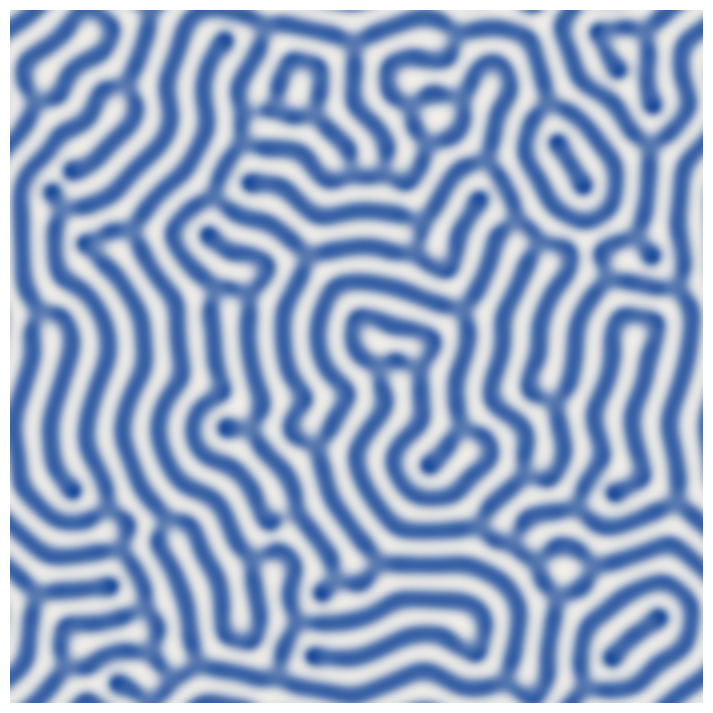

saved: assets/outputs/ch10_showpiece.png


In [10]:
# regenerate this chapter's showpiece: the grown labyrinth, indigo on paper
showpiece = turing_art("maze", low="#F2EFE9", high="#1B4B9B",
                       size=320, steps=11000, seed=10, figsize=9)
saved_path = save_artwork(showpiece, "showpiece", chapter=10)